# 5.8.1

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../')
from common import *

In [2]:
# Instrumental temperature uncertainty (added automatically)
sigma_t_instr = 20.0  # K

## Модель АЧТ

In [3]:
# модель АЧТ
# меняем мощность нагрева нити пирометра, ждем пока яркость будет как у АЧТ (T = 900 C)

k_termopara = 0.041 # mV / `C
T_termopara = [42.75, 43.16, 43.87, 43.94] # mV
T_pirometr = [1056, 1082, 1086, 1097] # `C
I_ = 1.007 # A - верний прибор, потом 0.995

In [4]:
T_termopara = [round(t / k_termopara + 273 + 20, 1) for t in T_termopara]
T_pirometr = [t + 273 for t in T_pirometr]
T_pirometr, T_termopara

([1329, 1355, 1359, 1370], [1335.7, 1345.7, 1363.0, 1364.7])

## Кольца

In [5]:
# определим температуру поверхности трубки по пирометру
T_truba = [824, 815] # C

# кольца в пирометре видны задом наперед. Здесь левое и правое - в окуляре пирометра
T_left = [750, 752] # C - довольно хорошо
T_right = [803, 829] # C - кольцо было нагрето неравномерно
# есть на видео

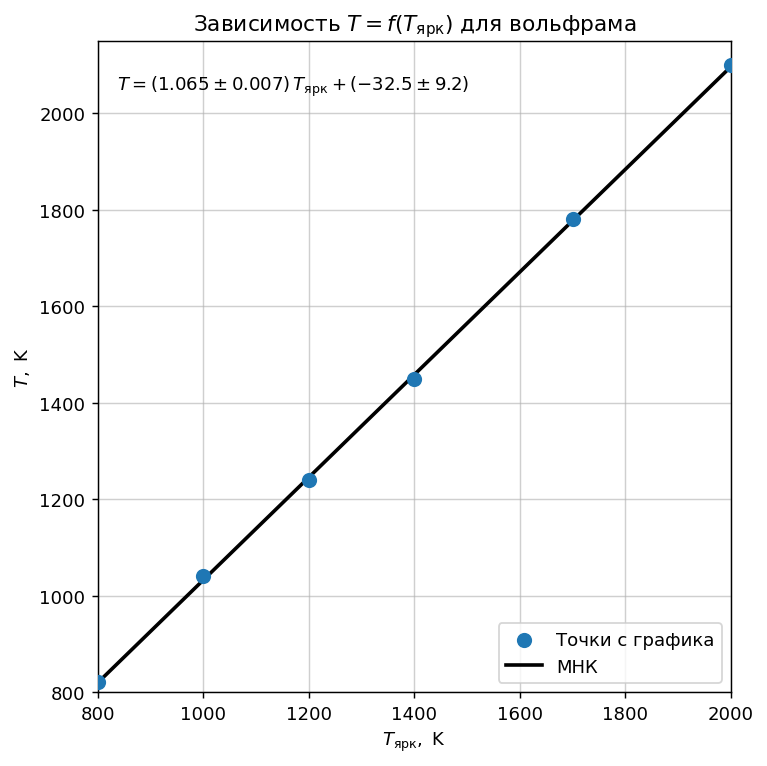

In [6]:
x_pts = np.array([800, 1000, 1200, 1400, 1700, 2000], float)
y_pts = np.array([820, 1040, 1240, 1450, 1780, 2100], float)

k, b, sk, sb = LeastSquares(x_pts, y_pts)

XMIN, XMAX = 800, 2000
YMIN, YMAX = 800, 2150

xf = np.linspace(XMIN, XMAX, 400)
yf = k*xf + b

fig, ax = plt.subplots(figsize=(6, 6), dpi=130)
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
ax.grid(True, which='major', linewidth=0.8, alpha=0.6)

ax.scatter(x_pts, y_pts, s=55, zorder=3, label='Точки с графика')

ax.plot(xf, yf, 'k-', lw=2, label='МНК')

ax.set_xlabel(r'$T_{\mathrm{ярк}},\ \mathrm{K}$')
ax.set_ylabel(r'$T,\ \mathrm{K}$')
ax.set_title(r'Зависимость $T = f(T_{\mathrm{ярк}})$ для вольфрама')

ax.text(0.03, 0.95,
        rf'$T = ({k:.3f}\pm{sk:.3f})\,T_{{\mathrm{{ярк}}}} + ({b:.1f}\pm{sb:.1f})$',
        transform=ax.transAxes, va='top')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [7]:
k, b

(np.float64(1.0648241206030151), np.float64(-32.51256281407041))

## Проверка Стефана Больцмана

In [8]:
# для лампы накаливания
T_lamp = [  892,   990,  1164,  1232,  1295,  1450,  1596,  1628,  1650,  1750,  1840,  1942] # C
T_lamp = [t + 273 for t in T_lamp]
I      = [0.512, 0.621, 0.631, 0.653, 0.697, 0.801, 0.855, 0.875, 0.906, 0.966, 1.003, 1.062] # A
V      = [ 1.53,  2.48,  2.59,  2.82,  3.23,  4.34,  4.97,  5.21,  5.58,  6.33,  6.82,  7.63] # V

,"T_ярк, K","T_терм, K","σ_T, K","I, A","σ_I, A","V, V","σ_V, V","W, W","σ_W, W"
0,1165,1208.0,11.9,0.512,0.001,1.53,0.01,0.783,0.005
1,1263,1312.4,12.3,0.621,0.001,2.48,0.01,1.540,0.007
2,1437,1497.6,13.1,0.631,0.001,2.59,0.01,1.634,0.007
3,1505,1570.0,13.4,0.653,0.001,2.82,0.01,1.841,0.007
4,1568,1637.1,13.7,0.697,0.001,3.23,0.01,2.251,0.008
5,1723,1802.2,14.5,0.801,0.001,4.34,0.01,3.476,0.009
6,1869,1957.6,15.2,0.855,0.001,4.97,0.01,4.249,0.010
7,1901,1991.7,15.4,0.875,0.001,5.21,0.01,4.559,0.010
8,1923,2015.1,15.5,0.906,0.001,5.58,0.01,5.055,0.011
9,2023,2121.6,16.1,0.966,0.001,6.33,0.01,6.115,0.012


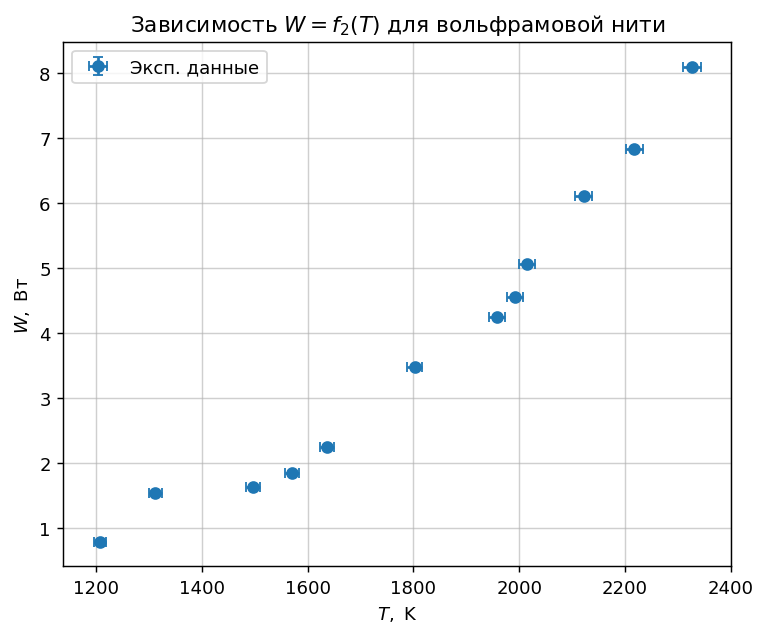

In [ ]:
# --- термодинамическая температура по аппроксимации ---
T_lamp = np.array(T_lamp)
I = np.array(I)
V = np.array(V)
T = k * T_lamp + b

# --- погрешность температуры по формулам распространения ошибок ---
sigma_T = np.sqrt((T_lamp * sk)**2 + sb**2)
sigma_I = 0.001  # A
sigma_V = 0.01   # V

# --- мощность нити ---
W = I * V  # Вт
sigma_W = W * np.sqrt((sigma_I / I)**2 + (sigma_V / V)**2)

# --- вывод числовой таблицы ---
import pandas as pd
df = pd.DataFrame({
    "T_ярк, K": np.round(T_lamp, 1),
    "T_терм, K": np.round(T, 1),
    "σ_T, K": np.round(sigma_T, 1),
    "I, A": I,
    "σ_I, A": sigma_I,
    "V, V": V,
    "σ_V, V": sigma_V,
    "W, W": np.round(W, 3),
    "σ_W, W": np.round(sigma_W, 3)
})
display(df)

# --- построение графика W = f(T) ---
plt.figure(figsize=(6,5), dpi=130)
plt.errorbar(T, W, xerr=sigma_T, yerr=sigma_W, fmt='o', capsize=3, label='Эксп. данные')
# plt.plot(T, W, 'k-', alpha=0.6)
plt.xlabel(r'$T,\ \mathrm{K}$')
plt.ylabel(r'$W,\ \mathrm{Вт}$')
plt.title(r'Зависимость $W = f_2(T)$ для вольфрамовой нити')
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

sigma_T = (sigma_T**2 + sigma_t_instr**2)**0.5


,"T_ярк, K",ε_T,"T, K","W, W"
0,1165,0.453,1208.0,0.783
1,1263,0.451,1312.4,1.540
2,1437,0.447,1497.6,1.634
3,1505,0.446,1570.0,1.841
4,1568,0.444,1637.1,2.251
5,1723,0.441,1802.2,3.476
6,1869,0.438,1957.6,4.249
7,1901,0.437,1991.7,4.559
8,1923,0.437,2015.1,5.055
9,2023,0.435,2121.6,6.115


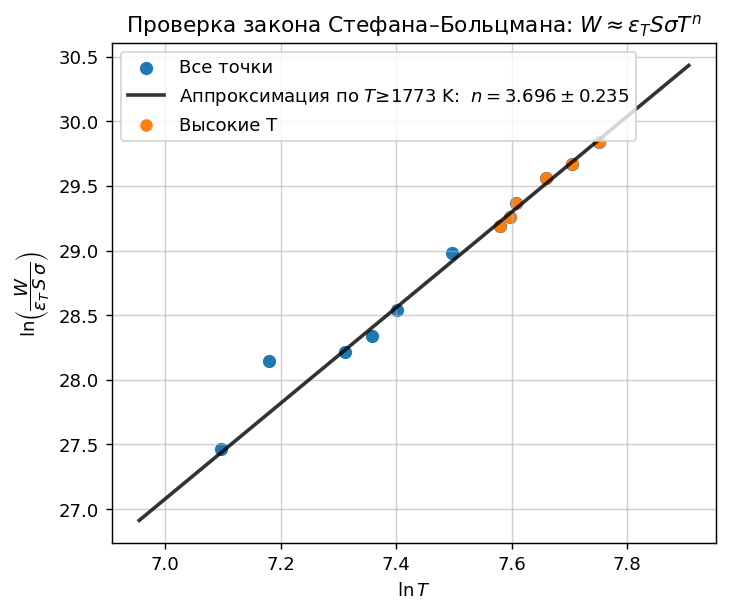

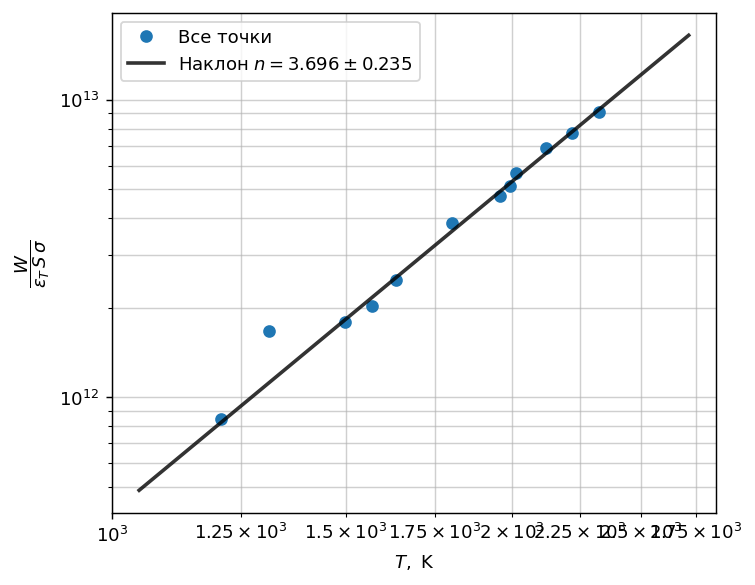

Оценка показателя степени n (T ≥ 1773 K): n = 3.696 ± 0.235


In [10]:
# Температуры таблицы (K):
eps_T_tab_T    = np.array([800,   900,   1000,  1100,  1200,  1300,  1400,  1500,  1600,  1700,  1800,  1900,  2000], float)
# eps_T_tab_vals = np.array([0.067, 0.081, 0.105, 0.119, 0.133, 0.144, 0.164, 0.179, 0.195, 0.209, 0.223, 0.236, 0.249], float)
eps_T_tab_vals = np.array([0.460, 0.458, 0.456, 0.454, 0.452, 0.450, 0.448, 0.446, 0.443, 0.441, 0.439, 0.437, 0.435], float)
# Соответствующие ε_T (столбец ε_T). ЗАМЕНИТЕ ЗНАЧЕНИЯ НИЖЕ на данные вашей таблицы:

# Линейная интерполяция ε_T под ваши температуры T:
eps_T = np.interp(T_lamp, eps_T_tab_T, eps_T_tab_vals)

# --- 4) Пересчёт термодинамической температуры и мощностей ---
T = k * T_lamp + b
sigma_T = np.sqrt((T_lamp * sk)**2 + sb**2)

W = I * V
sigma_W = W * np.sqrt((sigma_I / I)**2 + (sigma_V / V)**2)

# --- 5) Подготовка к логарифмическому анализу ---
sigma = 5.670374419e-8
S = 0.36e-4  # 0.36 см^2 -> м^2
B = S * sigma

# Используем форму: ln(W / (ε_T * B)) = n * ln T
x = np.log(T)
y = np.log(W / (eps_T * B))

mask_hi = T >= 1805.0
x_hi, y_hi = x[mask_hi], y[mask_hi]

# --- 6) Оценка n и константы (обычная МНК для прямой) ---
n, c, sigma_n, sigma_c = LeastSquares(x_hi, y_hi)

# --- 7) Таблица-итог для контроля ---
df = pd.DataFrame({
    "T_ярк, K": np.round(T_lamp,1),
    "ε_T": np.round(eps_T,3),
    "T, K": np.round(T,1),
    "W, W": np.round(W,3)
})
display(df)

# --- 8) Графики в лог-масштабе ---
# (а) Полные данные: ln(W/(ε_T B)) vs ln T
import matplotlib.ticker as mt
xx = np.linspace(x.min()*0.98, x.max()*1.02, 200)
yy = n*xx + c

plt.figure(figsize=(6,5), dpi=130)
plt.scatter(x, y, s=40, label='Все точки')
plt.plot(xx, yy, 'k', lw=2, alpha=0.8, label=fr'Аппроксимация по $T ≥ 1773$ K:  $n={n:.3f}\pm{sigma_n:.3f}$')
plt.scatter(x_hi, y_hi, s=35, label='Высокие T')
plt.xlabel(r'$\ln T$')
plt.ylabel(r'$\ln\!\left(\dfrac{W}{\varepsilon_T\,S\,\sigma}\right)$')
plt.title(r'Проверка закона Стефана–Больцмана: $W \approx \varepsilon_T S\sigma T^n$')
plt.grid(True, alpha=0.6)
plt.legend()
plt.show()

# (б) Тот же график, но в осях T и W (лог-лог)
plt.figure(figsize=(6,5), dpi=130)
plt.loglog(T, W/(eps_T*B), 'o', label='Все точки')
plt.loglog(np.exp(xx), np.exp(yy), 'k', lw=2, alpha=0.8, label=fr'Наклон $n={n:.3f}\pm{sigma_n:.3f}$')
plt.xlabel(r'$T,\ \mathrm{K}$')
plt.ylabel(r'$\dfrac{W}{\varepsilon_T\,S\,\sigma}$')
plt.grid(True, which='both', alpha=0.6)
plt.legend()
plt.show()

print(f"Оценка показателя степени n (T ≥ 1773 K): n = {n:.3f} ± {sigma_n:.3f}")

# Added: account for instrumental T uncertainty (20 K)
sigma_T = (sigma_T**2 + sigma_t_instr**2)**0.5


In [11]:
eps_T_tab_T    = np.array([800,   900,   1000,  1100,  1200,  1300,  1400,  1500,  1600,  1700,  1800,  1900,  2000], float)
eps_T_tab_vals = np.array([0.067, 0.081, 0.105, 0.119, 0.133, 0.144, 0.164, 0.179, 0.195, 0.209, 0.223, 0.236, 0.249], float)
# eps_T_tab_vals = np.array([0.460, 0.458, 0.456, 0.454, 0.452, 0.450, 0.448, 0.446, 0.443, 0.441, 0.439, 0.437, 0.435], float)
# Соответствующие ε_T (столбец ε_T). ЗАМЕНИТЕ ЗНАЧЕНИЯ НИЖЕ на данные вашей таблицы:

# Линейная интерполяция ε_T под ваши температуры T:
eps_T = np.interp(T_lamp, eps_T_tab_T, eps_T_tab_vals)

# отбор T > 1700 K
mask = T > 1805.0
T_sel, dT_sel = T[mask], sigma_T[mask]
W_sel, dW_sel = W[mask], sigma_W[mask]
eps_sel = eps_T[mask]

# σ_exp и её погрешность: σ = W/(ε S T^4)
sigma_exp = W_sel/(eps_sel*S*T_sel**4)
rel_var = (dW_sel/W_sel)**2 + (4*dT_sel/T_sel)**2  # погрешность ε_T и S считаем нулевой
d_sigma = sigma_exp*np.sqrt(rel_var)

# постоянная Планка из σ и её погрешность
kB = 1.380649e-23
c  = 299792458.0
h = ((2*np.pi**5*kB**4)/(15*c**2*sigma_exp))**(1/3)
dh = h*(1/3)*(d_sigma/sigma_exp)

sigma_mean = np.mean(sigma_exp)
d_sigma_mean = np.sqrt(np.sum(d_sigma**2))

h_mean = ((2*np.pi**5*kB**4)/(15*c**2*sigma_mean))**(1/3)
dh_mean = h_mean*(1/3)*(d_sigma_mean/sigma_mean)

tbl = pd.DataFrame({
    "T, K": np.round(T_sel, 1),
    "σ_T, K": np.round(dT_sel, 1),
    "ε_T": np.round(eps_sel, 3),
    "W, W": np.round(W_sel, 3),
    "σ_W, W": np.round(dW_sel, 3),
    "σ = W/(ε S T^4), W·m^-2·K^-4": sigma_exp,
    "σ(σ), W·m^-2·K^-4": d_sigma,
    "h, J·s": h,
    "σ(h), J·s": dh
})
display(tbl)

print(f"Взвешенная σ: {sigma_mean:.6e} ± {d_sigma_mean:.6e}  W·m^-2·K^-4")
print("Справочная σ₀ = 5.670374419e-8 W·m^-2·K^-4")
print(f"Оценка h: {h_mean:.6e} ± {dh_mean:.6e}  J·s")

,"T, K","σ_T, K",ε_T,"W, W","σ_W, W","σ = W/(ε S T^4), W·m^-2·K^-4","σ(σ), W·m^-2·K^-4","h, J·s","σ(h), J·s"
0,1957.6,25.2,0.232,4.249,0.010,3.464604e-08,1.782254e-09,7.808640e-34,1.338968e-35
1,1991.7,25.3,0.236,4.559,0.010,3.407851e-08,1.729929e-09,7.851749e-34,1.328596e-35
2,2015.1,25.3,0.239,5.055,0.011,3.563327e-08,1.792654e-09,7.735850e-34,1.297262e-35
3,2121.6,25.7,0.249,6.115,0.012,3.366690e-08,1.629401e-09,7.883618e-34,1.271830e-35
4,2217.5,26.0,0.249,6.840,0.012,3.156165e-08,1.478863e-09,8.055146e-34,1.258115e-35
5,2326.1,26.3,0.249,8.103,0.013,3.087834e-08,1.398212e-09,8.114130e-34,1.224728e-35


Взвешенная σ: 3.341078e-08 ± 4.022397e-09  W·m^-2·K^-4
Справочная σ₀ = 5.670374419e-8 W·m^-2·K^-4
Оценка h: 7.903711e-34 ± 3.171816e-35  J·s


## Неоновая лампочка

In [12]:
# у неоновой лампы нетепловое излучение (?)
T_neon = 805 # C